In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


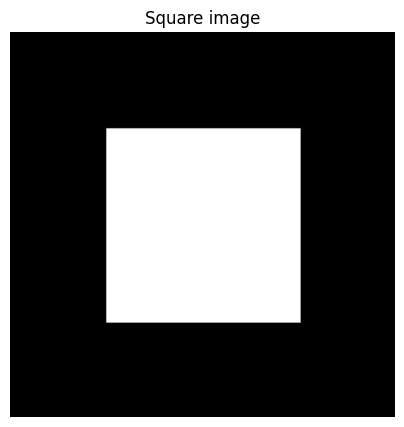

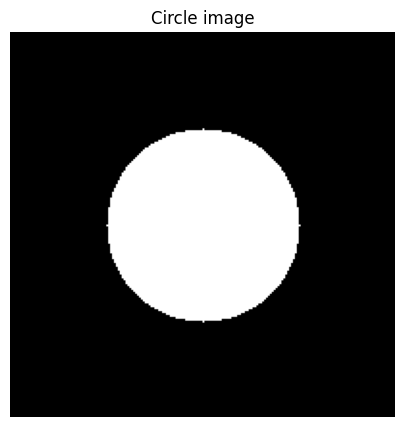

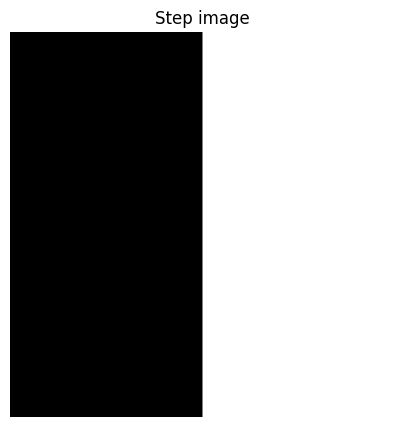

In [4]:
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

**Topic 1 — Simple image gradients**

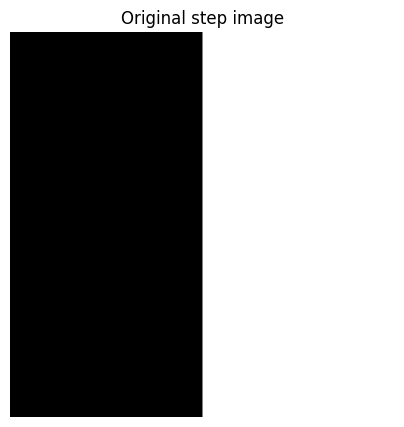

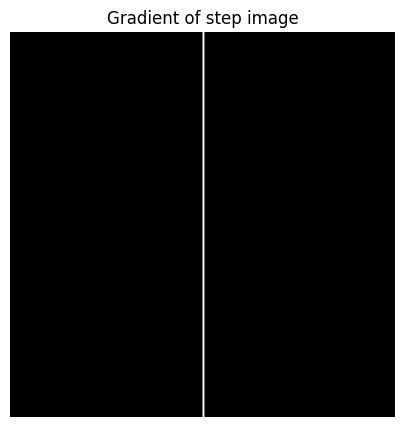

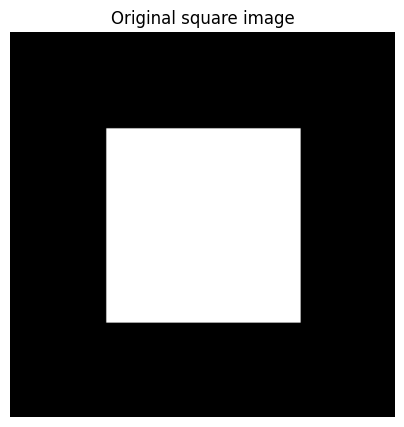

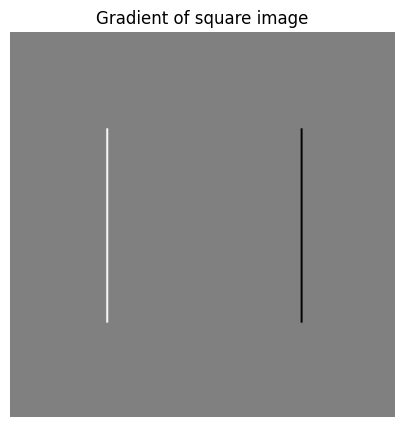

In [5]:
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

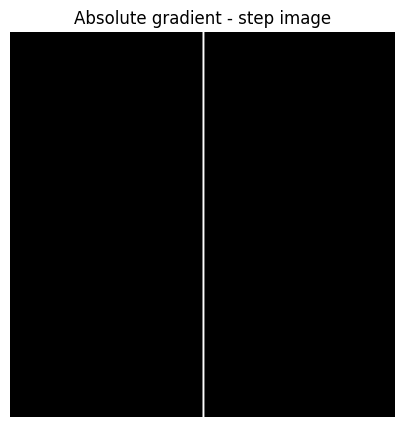

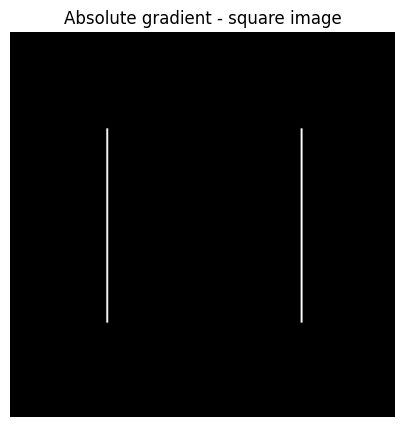

In [6]:
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

**Topic 2 — Sobel edge detector**

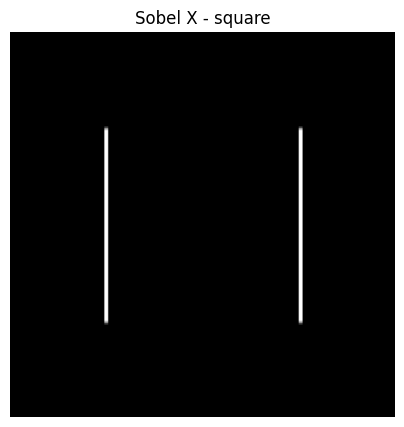

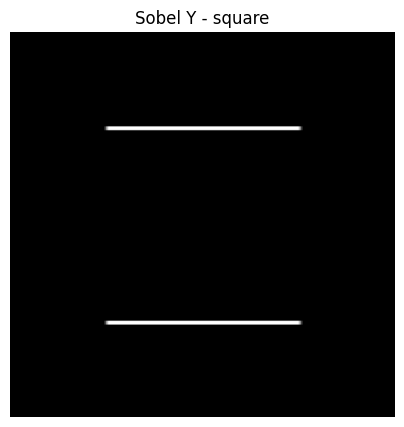

In [7]:
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

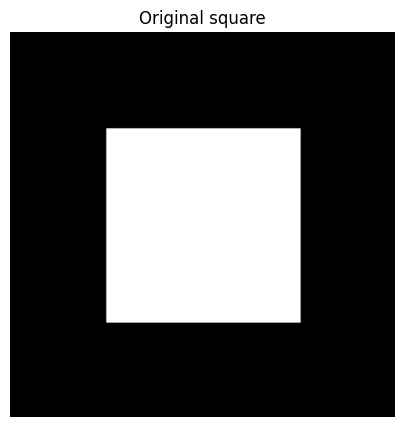

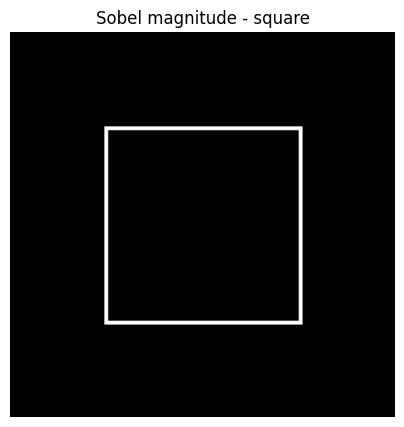

In [8]:
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

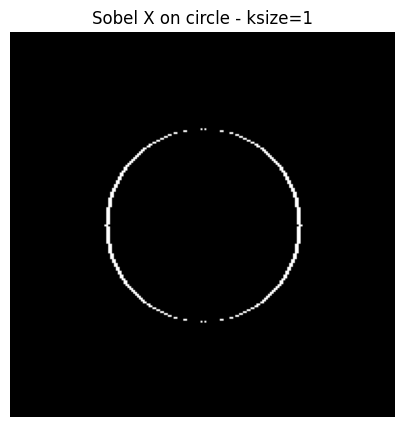

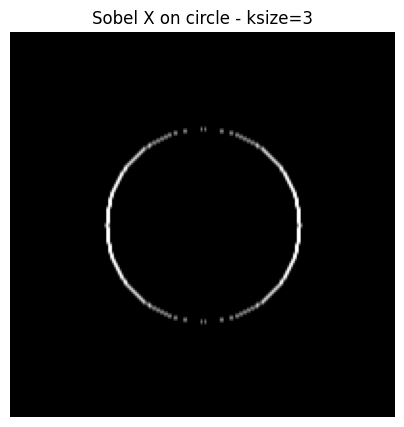

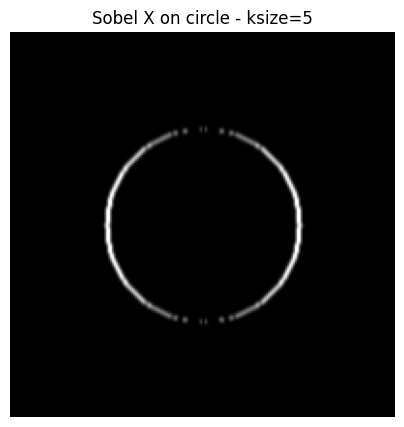

In [9]:
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

**Topic 3 — Laplacian edge detector**

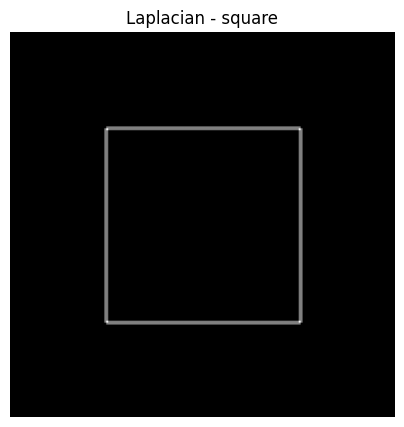

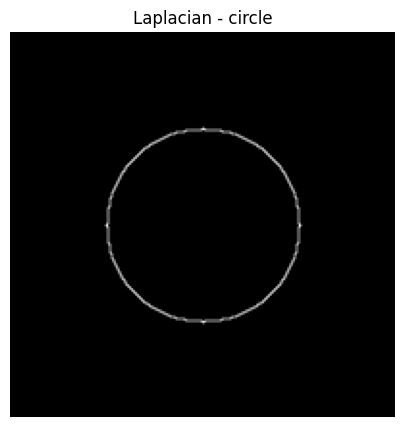

In [10]:
lap_square = cv2.Laplacian(img_square, cv2.CV_64F)
lap_circle = cv2.Laplacian(img_circle, cv2.CV_64F)

show(np.abs(lap_square), "Laplacian - square")
show(np.abs(lap_circle), "Laplacian - circle")

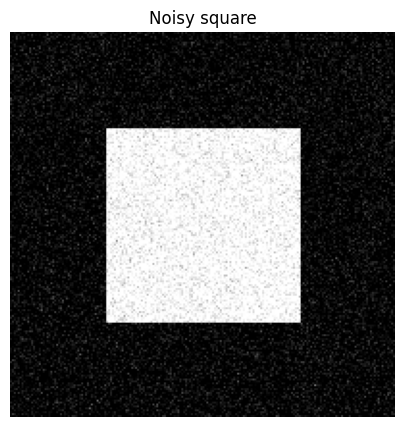

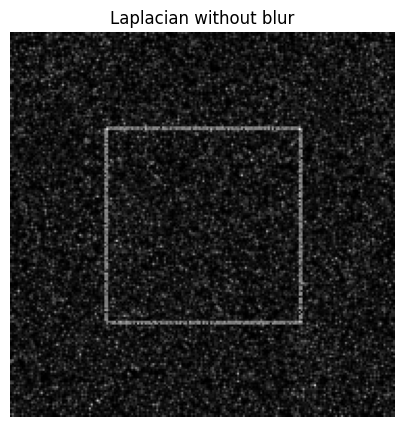

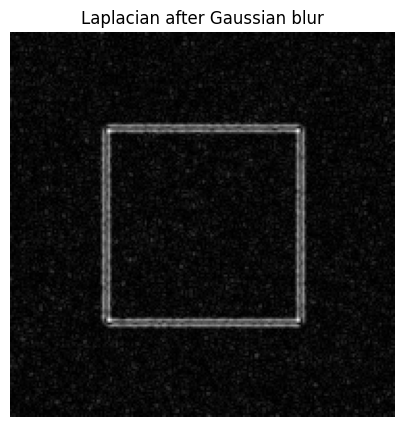

In [11]:
rng = np.random.default_rng(0)
noise = rng.normal(0, 25, img_square.shape)
img_square_noisy = np.clip(img_square + noise, 0, 255).astype(np.uint8)

lap_no_blur = cv2.Laplacian(img_square_noisy, cv2.CV_64F)

img_square_blur = cv2.GaussianBlur(img_square_noisy, (5, 5), 0)
lap_blur = cv2.Laplacian(img_square_blur, cv2.CV_64F)

show(img_square_noisy, "Noisy square")
show(np.abs(lap_no_blur), "Laplacian without blur")
show(np.abs(lap_blur), "Laplacian after Gaussian blur")

**Topic 4 — Canny edge detector**

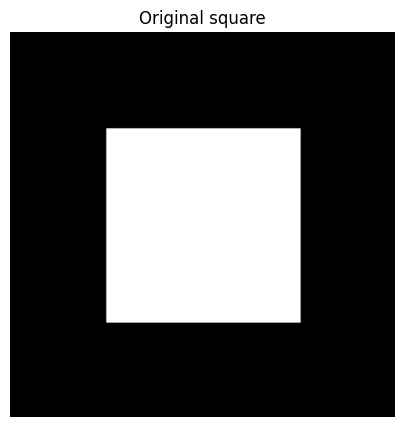

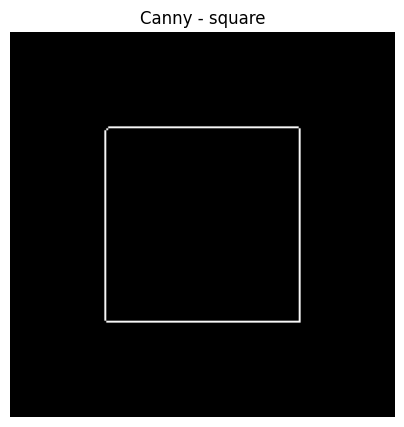

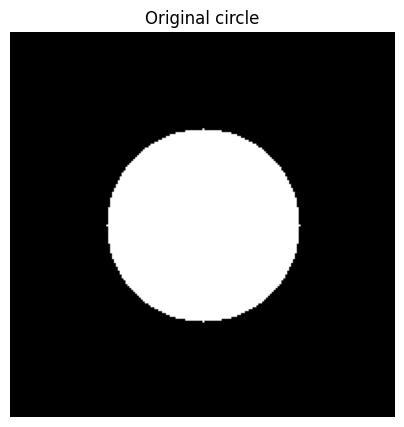

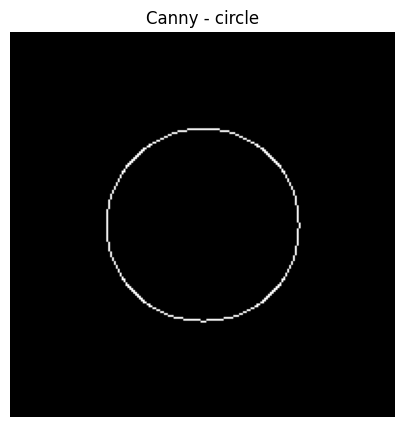

In [12]:
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

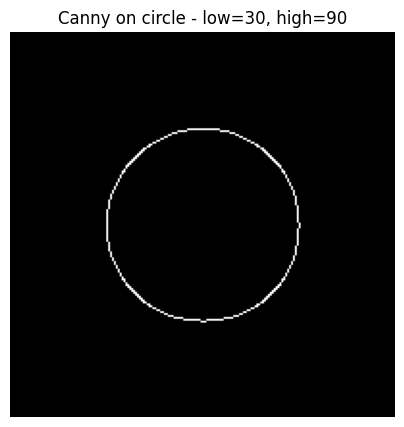

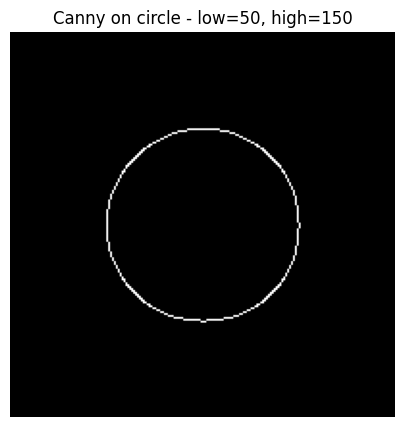

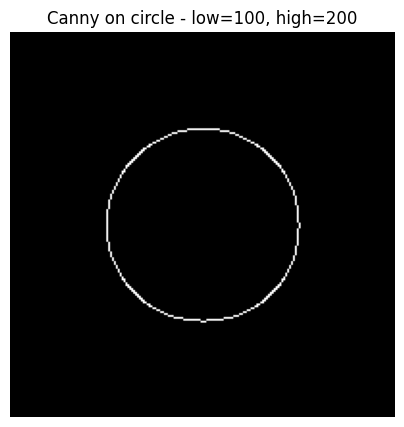

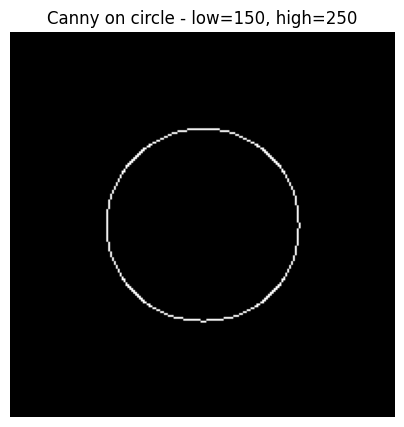

In [13]:
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

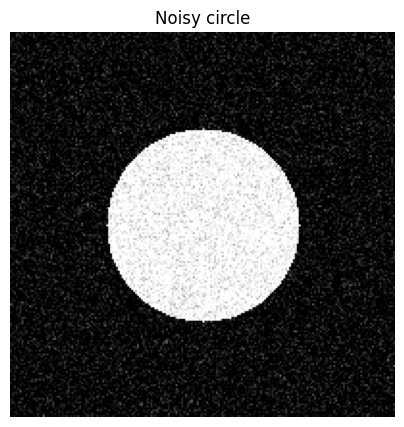

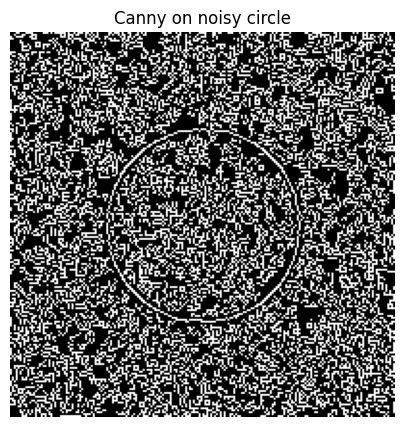

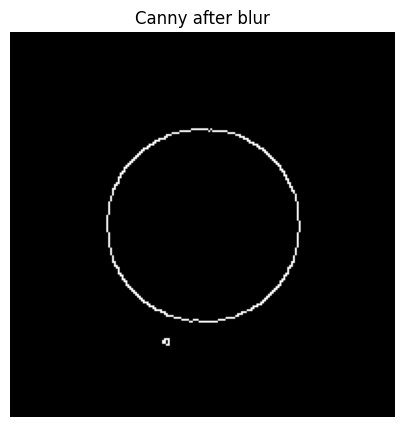

In [14]:
img_circle_noisy = np.clip(img_circle + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)

canny_noisy = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy, "Canny on noisy circle")
show(canny_blurred, "Canny after blur")